In [104]:
import sys, os
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

In [105]:
def meanmanual(df):
    for i in range(df.shape[1]):
        col_sum = 0
        for j in range(df.shape[0]):
            col_sum += df.iat[j, i]
        col_mean = col_sum / df.shape[0]
        print(f"Mean of column {df.columns[i]}: {col_mean}")

def medianmanual(data):
    if hasattr(data, "dropna"):
        data = data.dropna()
        
    col = sorted(data)
    n = len(col)
    mid = n // 2
    
    if n % 2 == 1:
        return col[mid]
    else:
        return (col[mid - 1] + col[mid]) / 2

def manualvar(df):
    for col in df.columns:
        data = df[col].dropna().tolist()
        n = len(data)
        
        mean = sum(data) / n
        
        sq_diff_sum = 0
        for value in data:
            sq_diff_sum += (value - mean) ** 2
        
        variance = sq_diff_sum / (n - 1)
        
        print("Variance of", col, "=", variance)

def manualstd(df):
    for col in df.columns:
        data = df[col].dropna().tolist()
        n = len(data)
        
        mean = sum(data) / n
        
        sq_diff_sum = 0
        for value in data:
            sq_diff_sum += (value - mean) ** 2
        
        variance = sq_diff_sum / (n - 1)
        std = math.sqrt(variance)
        
        print("Standard Deviation of", col, "=", std)

def manualiqr(df):
    q = quartiles(df)
    
    for col in q:
        Q1, Q2, Q3 = q[col]
        IQR = Q3 - Q1
        print("IQR of", col, "=", IQR)

def quartiles(df):
    results = {}
    
    for column in df.columns:
        data = sorted(df[column].dropna())
        n = len(data)
        mid = n // 2
        
        Q2 = medianmanual(df[column])
        
        if n % 2 == 0:
            lower_half = data[:mid]
            upper_half = data[mid:]
        else:
            lower_half = data[:mid]
            upper_half = data[mid+1:]
        
        Q1 = medianmanual(lower_half)
        Q3 = medianmanual(upper_half)
        results[column] = (Q1, Q2, Q3)
    
    return results

In [106]:
df = pd.read_csv("../Assignment_1/Assignment_1.csv")

In [107]:
def normal_distribution(x, mean, std):
    return (1 / (std * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mean) / std) ** 2)

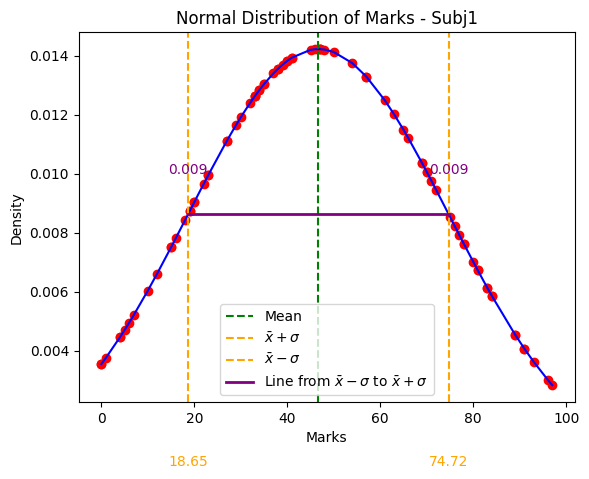

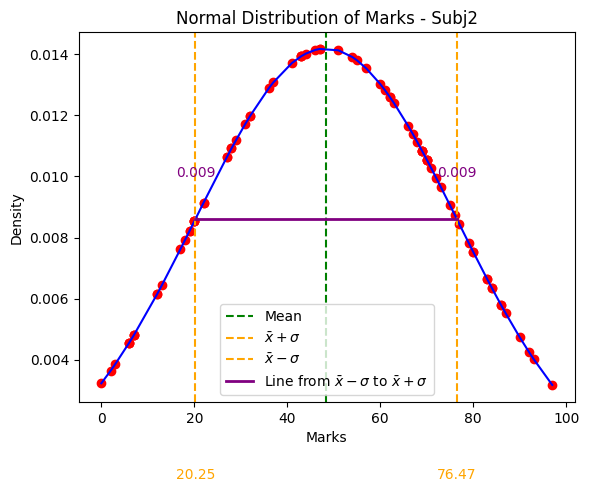

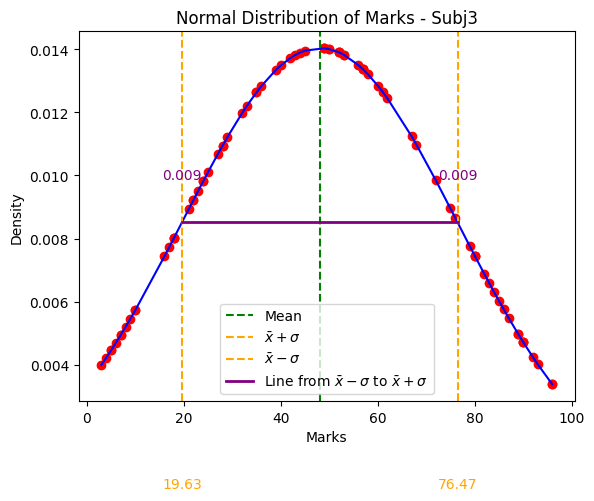

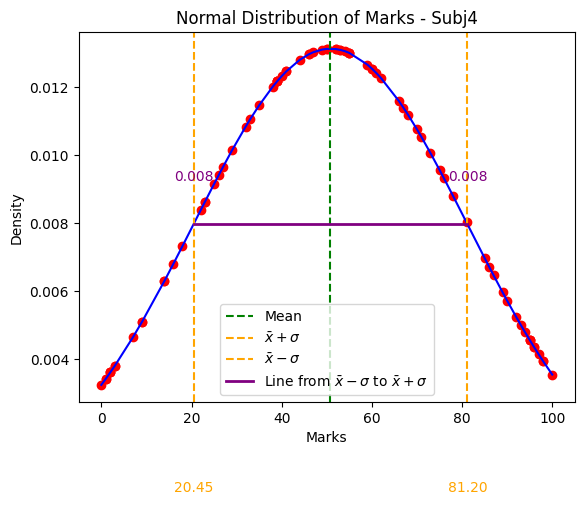

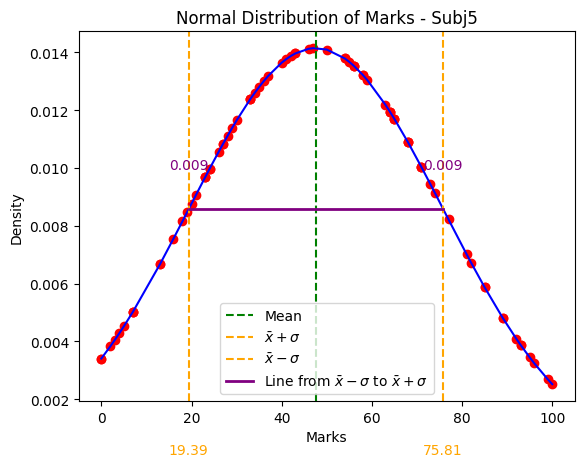

In [108]:
for col in df.columns[1:]:
    marks = df[col].dropna().tolist()
    
    n = len(marks)
    mean_marks = sum(marks) / n
    sq_diff_sum = sum((x - mean_marks) ** 2 for x in marks)
    var_marks = sq_diff_sum / (n - 1)
    std_marks = math.sqrt(var_marks)
    
    marks_sorted = sorted(marks)
    ndf = [normal_distribution(x, mean_marks, std_marks) for x in marks_sorted]

    plt.scatter(marks_sorted, ndf, color='red')
    plt.plot(marks_sorted, ndf, color='blue')
    plt.title(f"Normal Distribution of Marks - {col}")
    plt.xlabel("Marks")
    plt.ylabel("Density")
    plt.axvline(mean_marks, color='green', linestyle='--', label='Mean')
    plt.axvline(mean_marks + std_marks, color='orange', linestyle='--', label=r'$\bar{x} + \sigma$')
    plt.axvline(mean_marks - std_marks, color='orange', linestyle='--', label=r'$\bar{x} - \sigma$')

    x1, x2 = mean_marks + std_marks, mean_marks - std_marks
    y1, y2 = normal_distribution(x1, mean_marks, std_marks), normal_distribution(x2, mean_marks, std_marks)
    plt.plot([x1, x2], [y1, y2], color='purple', linestyle='-', linewidth=2, label=r'Line from $\bar{x}-\sigma$ to $\bar{x}+\sigma$')

    offset = 0.09 * max(ndf)

    plt.text(x1, 0, f"{x1:.2f}", ha='center', va='bottom', color='orange')
    plt.text(x2, 0, f"{x2:.2f}", ha='center', va='bottom', color='orange')


    plt.text(x1, y1 + offset, f"{y1:.3f}", ha='center', va='bottom', color='purple')
    plt.text(x2, y2 + offset, f"{y2:.3f}", ha='center', va='bottom', color='purple')
    plt.legend()
    plt.show()